## Simple outflow vizualiztion

In [1]:
import os
from datetime import datetime
from swmm_api.input_file import read_inp_file, SwmmInput, section_labels as sections
from swmm_api import read_inp_file, read_out_file, swmm5_run
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [2]:
def load_sim_to_df(sim_output_path):
    """ Takes SWMM FILE with outflow data and makes pd Dataframe
    sim_output_path: str, file name that have the swmm outflow data
    return: sim_df
    """
    sim_df = read_out_file(sim_output_path).to_frame()['system'][''][['runoff', 'outflow', 'rainfall']]
    sim_df.rename(columns={'runoff': 'SWMM runoff [CMS]', 'outflow':'SWMM outflow [CMS]', 'rainfall':'rainfall [mm/h]'}, inplace=True, errors='raise')
    sim_df.index = pd.to_datetime(sim_df.index)
    return sim_df

In [3]:
def load_runoff_obs_to_df(OBS_RUNOFF_DATA_PATH):
    """ Takes OBSERVATION FILE with runoff data and makes pd Dataframe
    :param output_path: str, path name that have the runoff data
    :return: df_obs_runoff
    """
    df_obs_runoff = pd.read_csv (OBS_RUNOFF_DATA_PATH + ".csv")
    df_obs_runoff.dropna(inplace = True) ; df_obs_runoff.rename(columns={'discharge_cms': 'OBS outflow [CMS]'} , inplace=True, errors='raise')
    df_obs_runoff["date_and_time"] =  pd.to_datetime(df_obs_runoff["date_and_time"], format='%d/%m/%Y %H:%M')
    df_obs_runoff = df_obs_runoff.set_index('date_and_time')
#     df_obs_runoff.drop(['Unnamed: 0'], axis=1, inplace=True)


    return df_obs_runoff
    
# df_runoff.to_pickle('df_runoff.pkl')

In [4]:
def data_5min_interpolate(df_to_interpolate):
    """ Takes df column and makes 5 min interpolation
    :param df_to_interpolate: pd, df with index datetime64 type
    :return: df_interpol
    """
    df_interpol = df_to_interpolate.resample('5min').mean()
#     df_interpol= df_interpol.interpolate(method='polynomial', order=3)
    df_interpol= df_interpol.interpolate(method='linear')
    return df_interpol

In [5]:
def observation_and_swmm_hydrograph(storm_df, date):
    """
    This function takes observation and SWMM model runoff and precipitation data and puts it in a hydrograph.
    Params:
     - storm_df: df, The DataFrame that includes the runoff and precipitation data
     - date: date of storm occurrence. Format: 'yyyy_mm_dd'
    Returns: a hydrograph plot for one subcatchment
    """
    
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.suptitle(storm_df.index.strftime('%d/%m/%Y')[0], fontsize=20)

    y_obs_runoff = storm_df['OBS outflow [CMS]']
    y_rainfall = storm_df['rainfall [mm/h]']
    y_sim_runoff = storm_df['SWMM outflow [CMS]']

    ax1 = sns.lineplot(ax=ax, data=y_obs_runoff, color='g', label='Observed outflow')
    ax2 = ax1.twinx()
#     ax2.set_ylabel('Rainfall ($mm/hr$)')

    sns.lineplot(ax=ax2, data=y_rainfall, color='b', label='Rainfall', alpha=0.4)
    ax2.fill_between(storm_df.index, 0, y_rainfall, alpha=0.4, color='b')
#     ax2.set_ylim(ymin=y_rainfall.max() + 50, ymax=0)
    ax2.set_ylim(ymin=70, ymax=0)
    ax1.set_ylim(ymin=0, ymax=2)
    

    sns.lineplot(ax=ax, data=y_sim_runoff, color='r', label='Simulated outflow')

    ax2.set_xlabel('Time', fontsize=18)
    ax2.set_ylabel('Rainfall ($mmhr^{-1}$)', fontsize=18)
    ax1.set_ylabel('Runoff ($m^{3}s^{-1}$)', fontsize=18)

    ax2.legend().remove()

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    handles = handles1 + handles2
    labels = labels1 + labels2
    ax.legend(handles, labels, loc='center right', fontsize=15)

    # set x-axis label format to %d/%m %H
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
    ax.tick_params(axis='x', labelsize=18, rotation=45)
    ax1.tick_params(axis='y', labelsize=18) ; ax2.tick_params(axis='y', labelsize=18)
    ax1.grid()

    return fig



In [6]:
def update_imperviousness_with_factor(subcatchment_dict, factor):
    """
    Update the imperviousness values of SubCatchment objects in a dictionary by a factor.

    Args:
        subcatchment_dict (dict): A dictionary containing SubCatchment objects as values with subcatchment names as keys.
        factor (float): The factor by which imperviousness values need to be powered.

    Returns:
        dict: The updated dictionary with imperviousness values powered by the factor.
    """
    # Loop through each subcatchment in the dictionary
    for index, (subcatchment_name, subcatchment) in enumerate(subcatchment_dict.items()):
#         initial_imperviousness = impervious_initial_values[index]
#         subcatchment.imperviousness = initial_imperviousness
        powered_imperviousness = subcatchment.imperviousness * factor
        # Update the imperviousness value for the current subcatchment with the powered imperviousness value
        subcatchment.imperviousness = powered_imperviousness


    # Return the updated dictionary
    return subcatchment_dict


def update_storage_with_factor(subareas_dict, factor):
    """
    Update the storage values of SubArea objects in a dictionary by a factor.

    Args:
        subareas_dict (dict): A dictionary containing SubArea objects as values with subarea names as keys.
        factor (float): The factor by which storage values need to be powered.

    Returns:
        dict: The updated dictionary with storage values powered by the factor.
    """
    # Loop through each subarea in the dictionary
    for subarea_name, subarea in subareas_dict.items():
        # Access the impervious and pervious storage values for the current subarea
        imp_storage = subarea.storage_imperv
        perv_storage = subarea.storage_perv
        # Multiply the impervious and pervious storage values by the factor
        powered_imp_storage = imp_storage * factor
        powered_perv_storage = perv_storage * factor
        # Update the storage values for the current subarea with the powered values
        subarea.storage_imperv = powered_imp_storage
        subarea.storage_perv = powered_perv_storage


    # Return the updated dictionary
    return subareas_dict


swmm5 D:\Development\RESEARCH\Gazelle_Valley\SWMM\20231119/Nahal_Rakfot_tryenderror.inp:   0%|          | 0/1 …

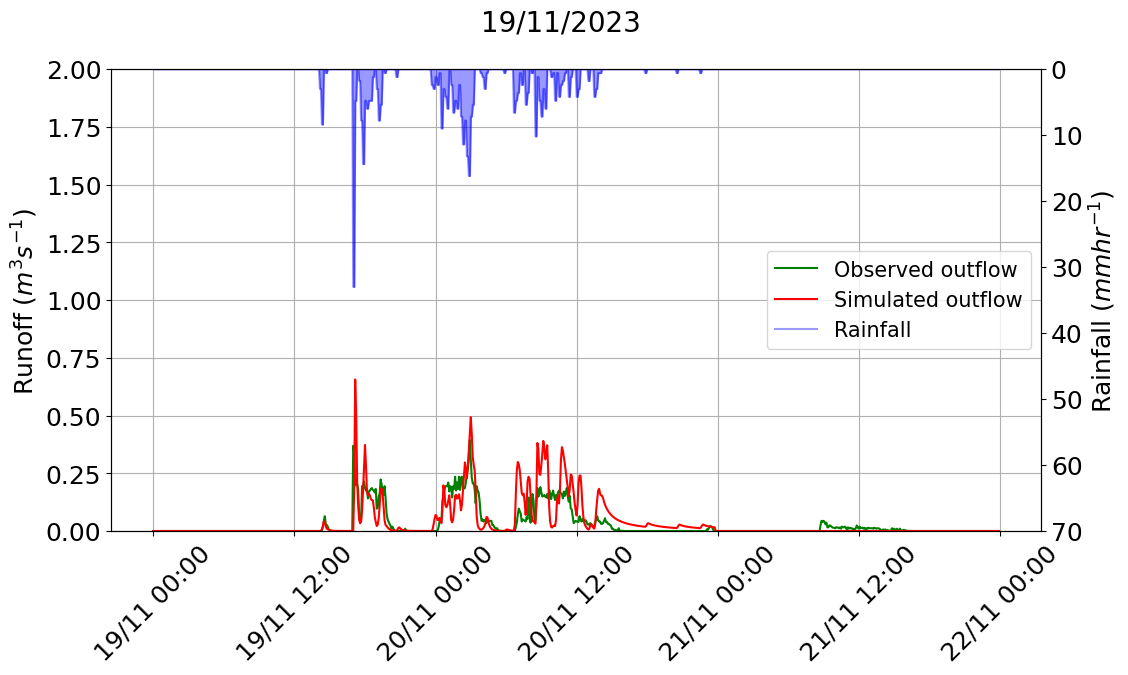

In [28]:
# sim_dir = r"D:\Development\RESEARCH\Gazelle_Valley\SWMM\20240318/"
# OBS_FILE = '2024_03_18'
sim_dir = r"D:\Development\RESEARCH\Gazelle_Valley\SWMM\20231119/"
OBS_FILE = '2023_11_19'

# sim_dir = r"D:\Development\RESEARCH\Gazelle_Valley\SWMM\20240110/"
# OBS_FILE = '2024_01_10'

obs_outflow_df = data_5min_interpolate(load_runoff_obs_to_df(sim_dir + OBS_FILE))


# sim_dir = os.path.join(sim_dir, date + '/')
INP_FILE = r"Nahal_Rakfot.inp"
inp = read_inp_file(os.path.join(sim_dir, INP_FILE))

subcatchment_d = dict(inp[sections.SUBCATCHMENTS])
subareas_d = dict(inp[sections.SUBAREAS])
update_imperviousness_with_factor(subcatchment_d, 0.25)
update_storage_with_factor(subareas_d, 80)

file_name = 'Nahal_Rakfot_tryenderror'
inp.write_file(os.path.join(sim_dir, file_name + '.inp'))
swmm5_run(os.path.join(sim_dir, file_name + '.inp'), progress_size=1)
OUT_FILE = file_name + '.out'

sim_df = load_sim_to_df(os.path.join(sim_dir, OUT_FILE))

storm_df = pd.concat([obs_outflow_df, sim_df], axis=1)
storm_df[storm_df < 0] = 0
storm_df = storm_df.fillna(0)


date = OBS_FILE
fig = observation_and_swmm_hydrograph(storm_df, date)


In [ ]:
subcatchment_d

In [ ]:
subareas_d